In [2]:
### Pipeline of data visualization for assembly codes. ###
#can split by year, etc. like other pipelines
# Date: 6/5/2025

# All graphs are comparable to those in manufacturing and mining files
#added a quantity v. price metric (as for the other 2 files too). 6/ 25

In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

#  CONFIGURATION 
base_dir = "../data/assembly"
country_code_file = "../ref/country_codes_V202501.csv"
category_dirs = [d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d))]
years = [2020]

# Load country codes
country_df = pd.read_csv(country_code_file)
country_lookup = dict(zip(country_df["country_code"], country_df["country_name"]))

# Color mapping per category (can be adjusted as needed)
category_colors = plt.get_cmap("tab20").colors
export_value = defaultdict(lambda: defaultdict(float))
export_quantity = defaultdict(lambda: defaultdict(float))

# Load trade data
for category in category_dirs:
    trade_path = os.path.join(base_dir, category, "trade_data.csv")
    if not os.path.exists(trade_path):
        continue
    try:
        df = pd.read_csv(trade_path)
        df = df.rename(columns={"i": "exporter", "j": "importer", "k": "hs_code", "v": "value", "q": "quantity"})
        df = df[df["year"].isin(years)]
        grouped = df.groupby("exporter").agg({"value": "sum", "quantity": "sum"}).reset_index()
        for _, row in grouped.iterrows():
            export_value[int(row["exporter"])][category] += row["value"]
            export_quantity[int(row["exporter"])][category] += row["quantity"]
    except Exception as e:
        print(f"[ERROR] Failed to process {category}: {e}")

value_df = pd.DataFrame(export_value).T.fillna(0)
quantity_df = pd.DataFrame(export_quantity).T.fillna(0)
value_df.index = value_df.index.map(lambda x: country_lookup.get(x, f"Code {x}"))
quantity_df.index = quantity_df.index.map(lambda x: country_lookup.get(x, f"Code {x}"))
total_value = value_df.sum(axis=1)
top_exporters = total_value.nlargest(20).index
value_df = value_df.loc[top_exporters]
quantity_df = quantity_df.loc[top_exporters]
valid_categories = value_df.columns
colors = [category_colors[i % len(category_colors)] for i in range(len(valid_categories))]


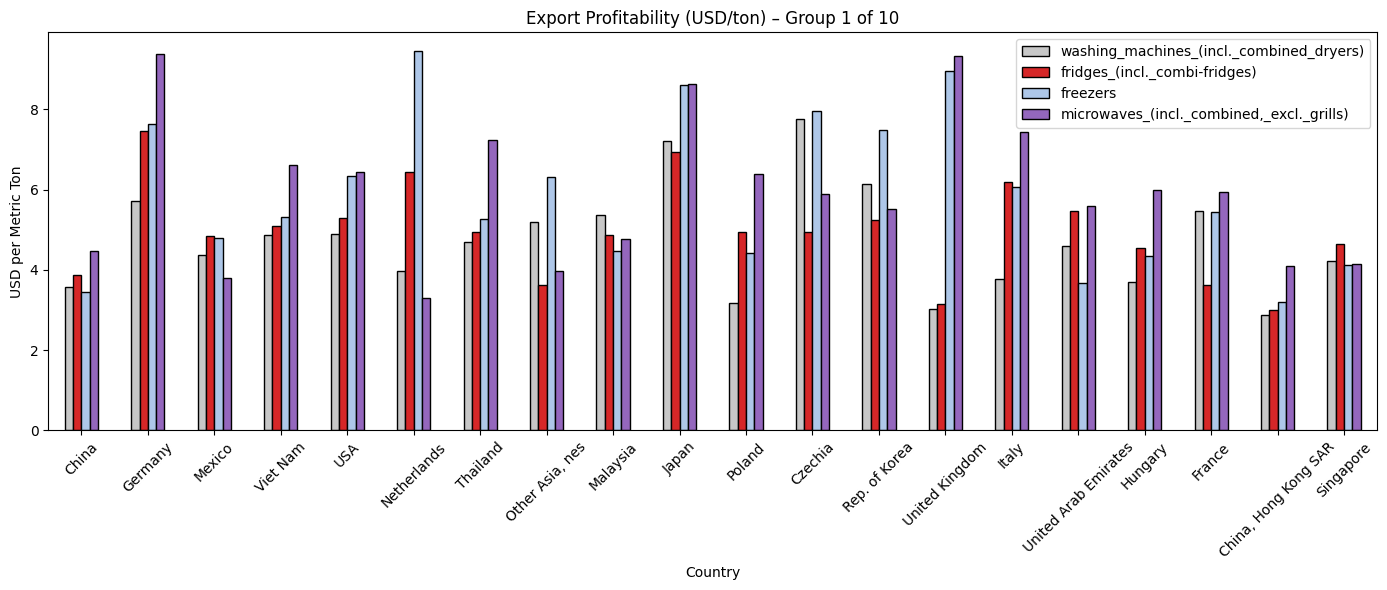

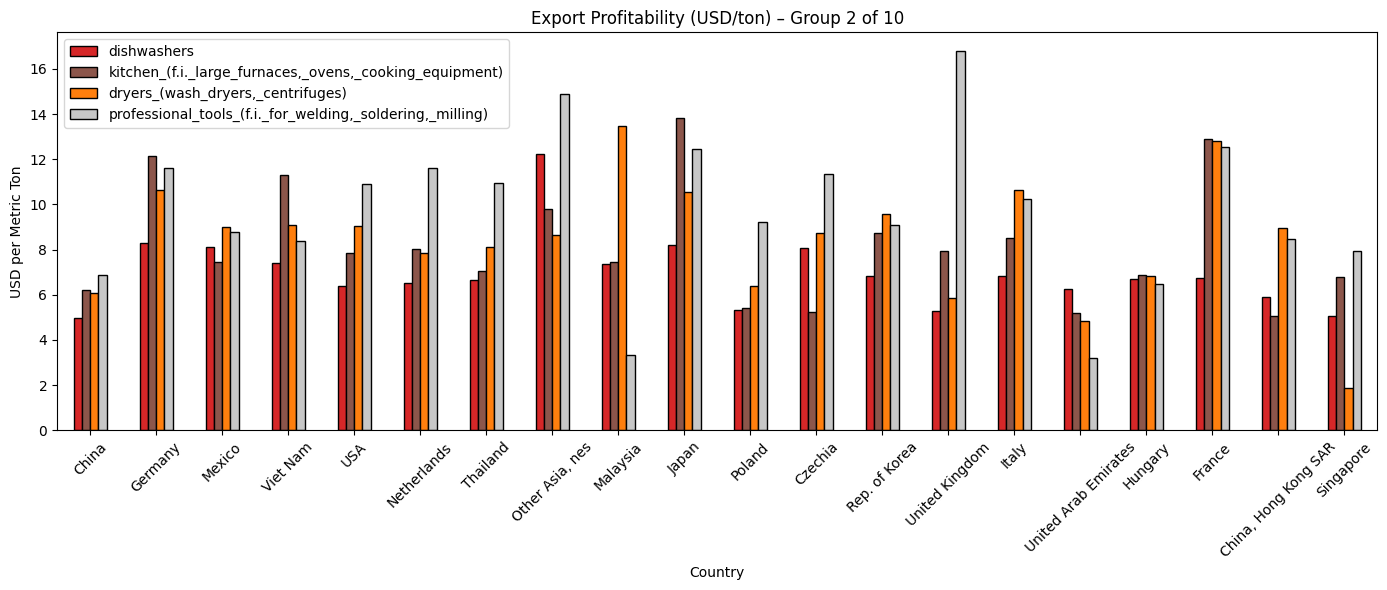

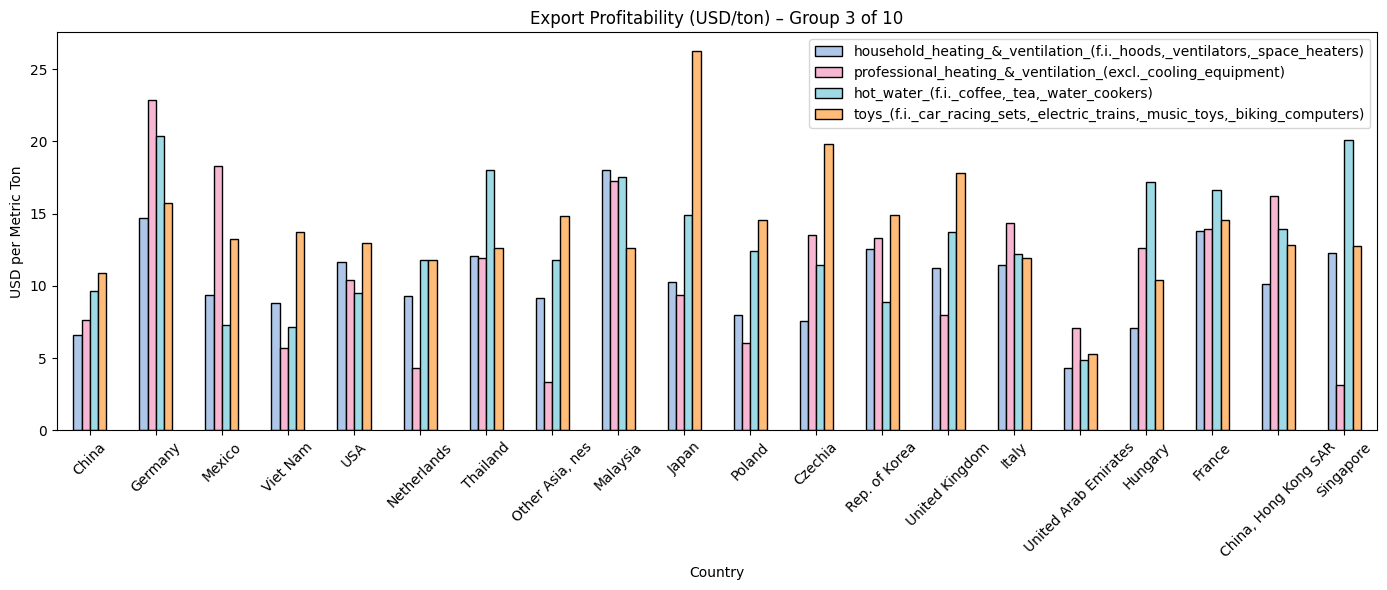

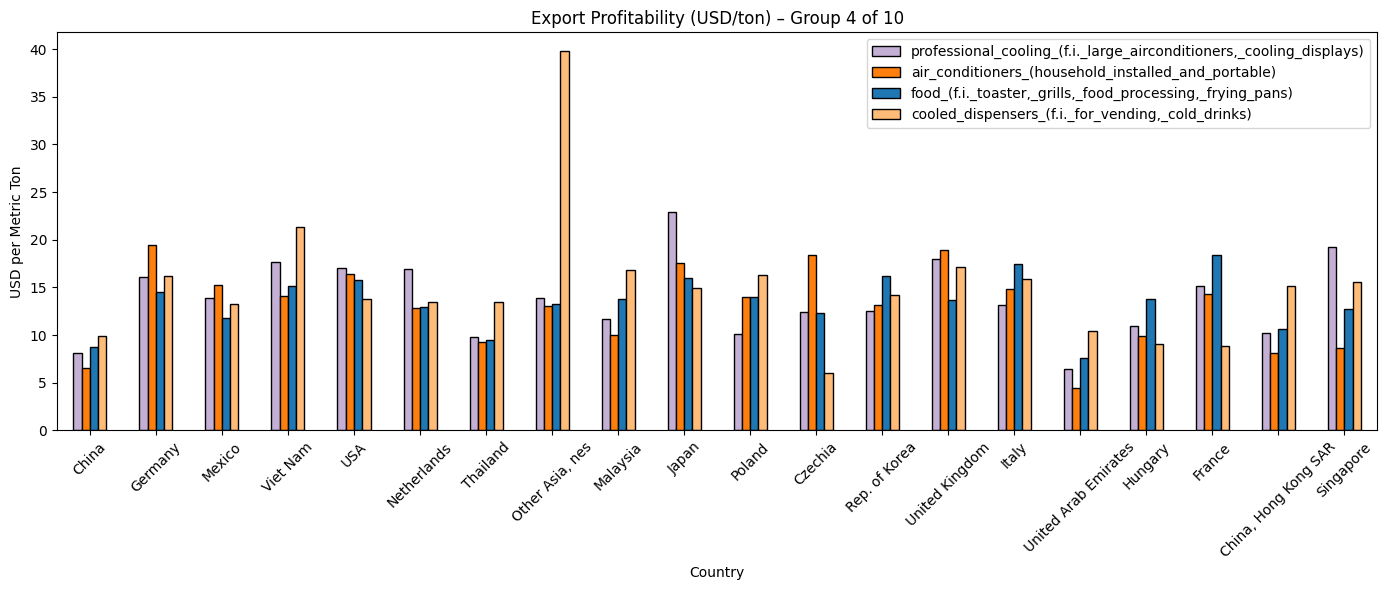

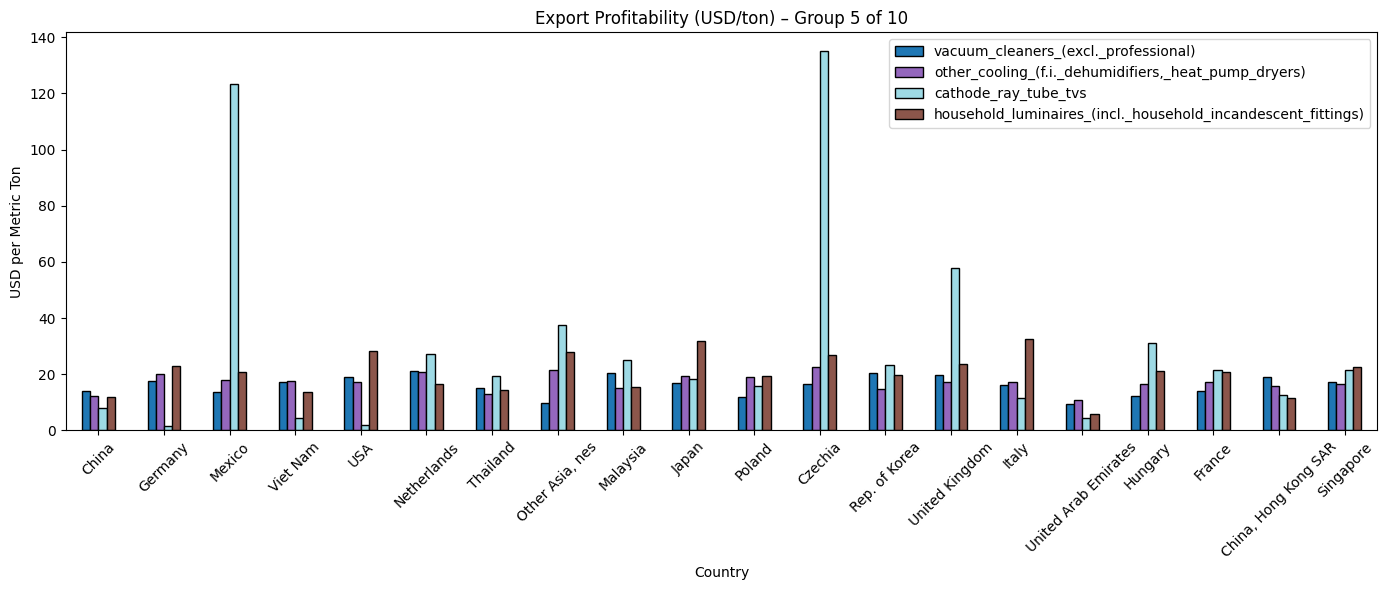

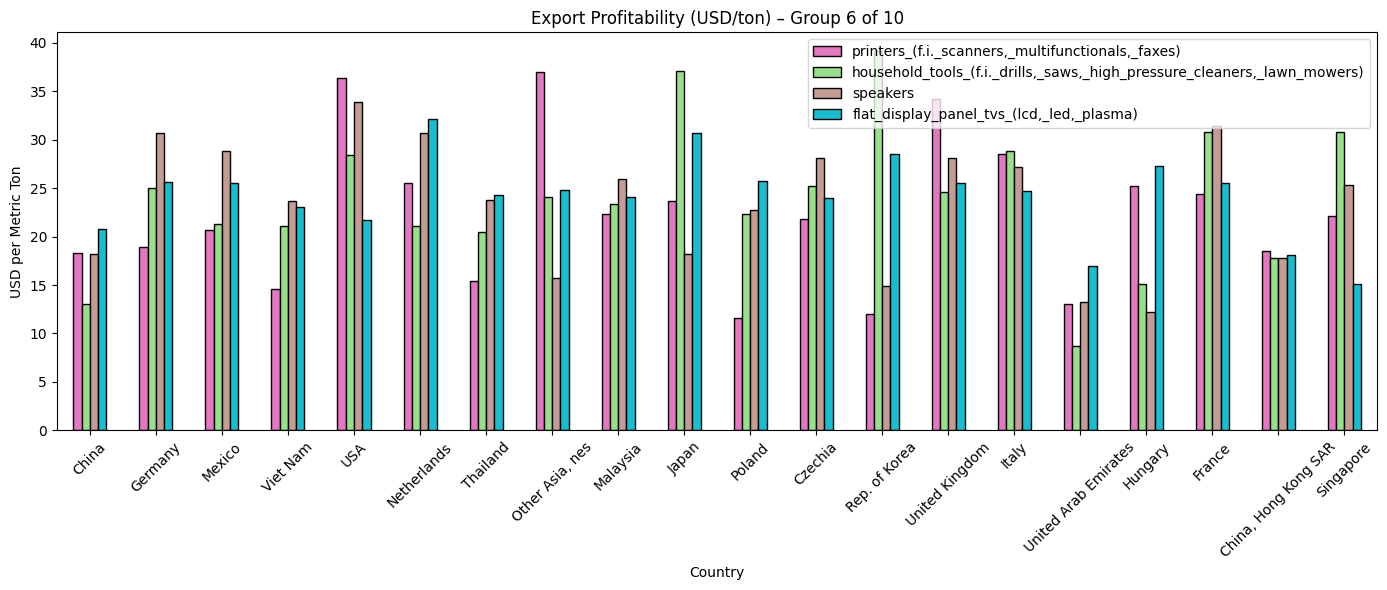

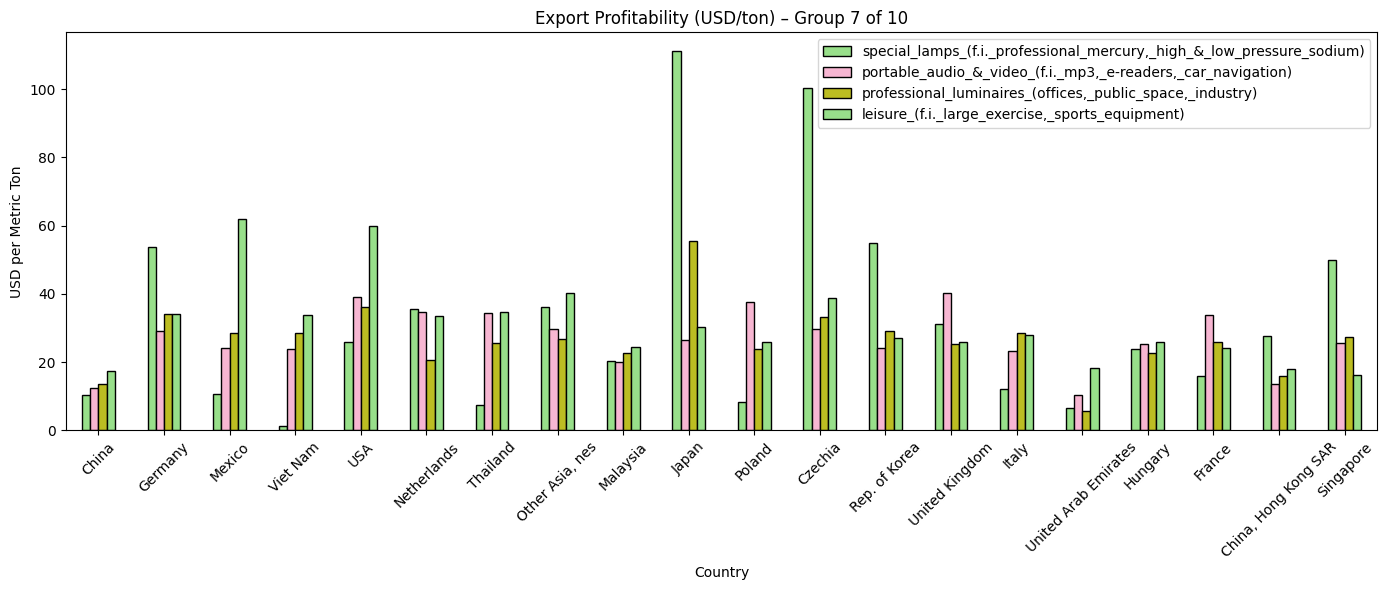

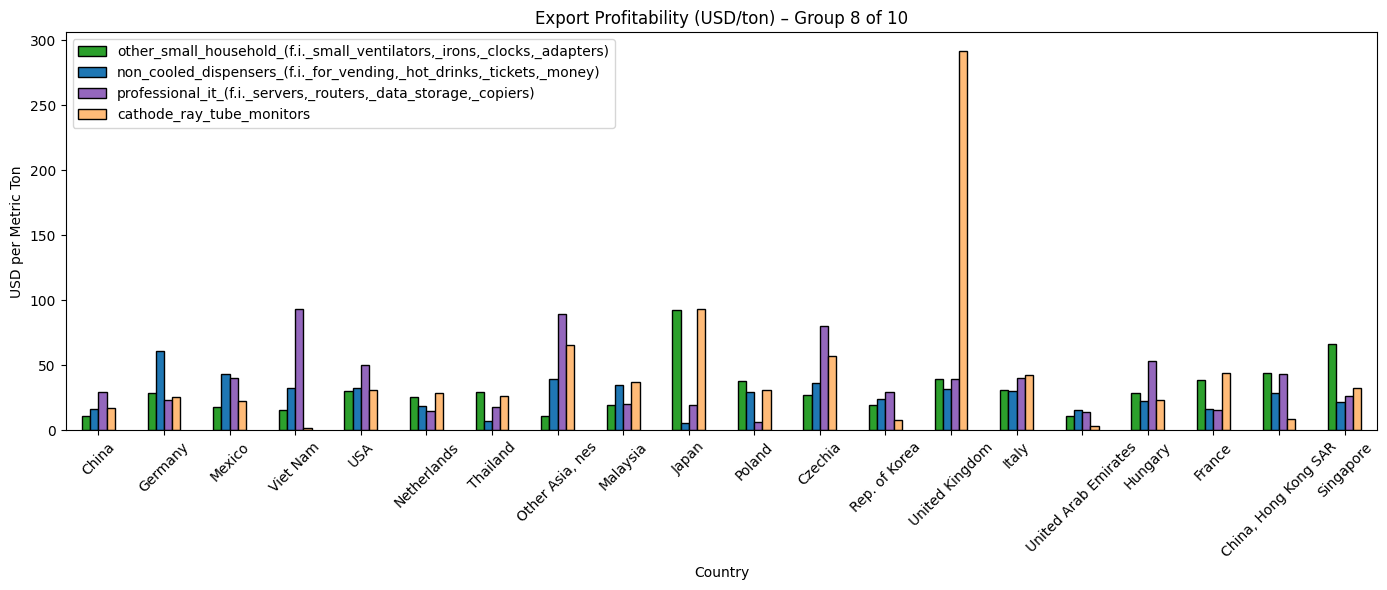

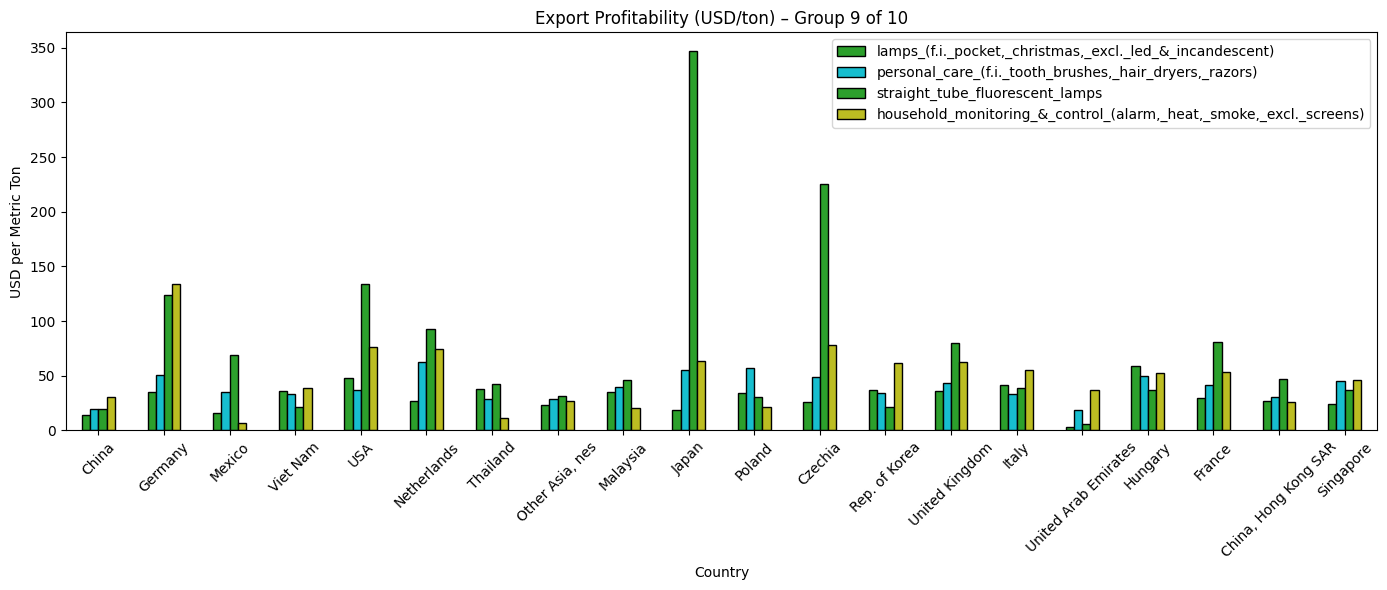

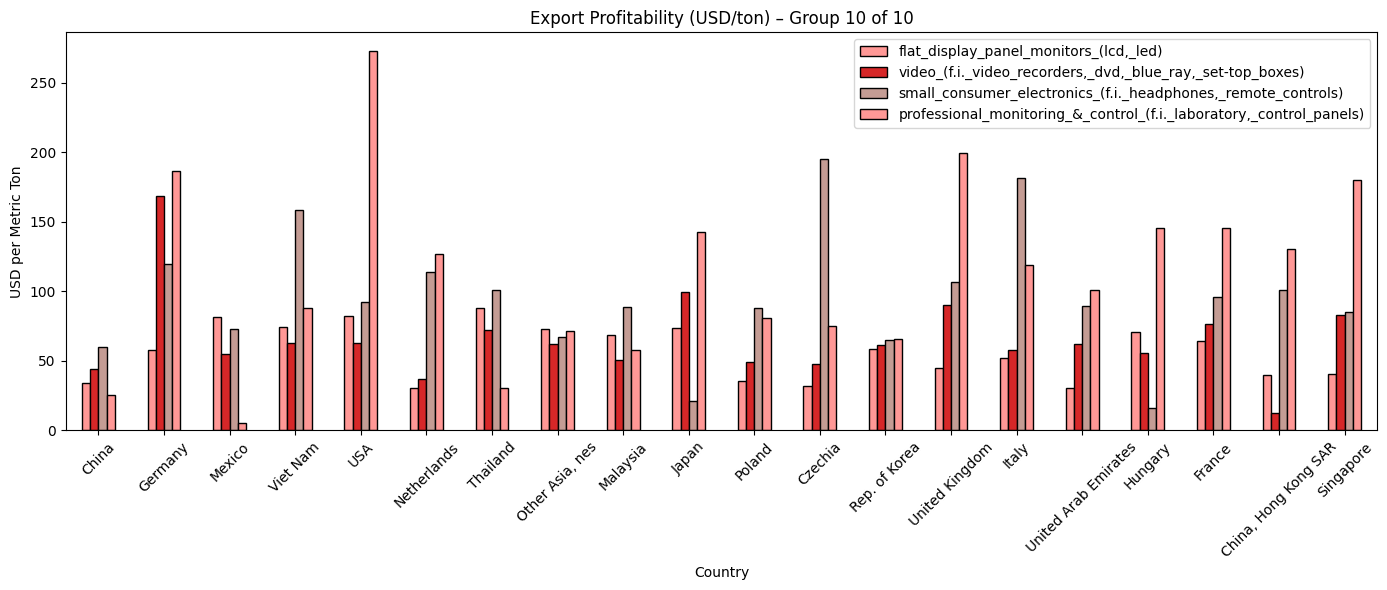

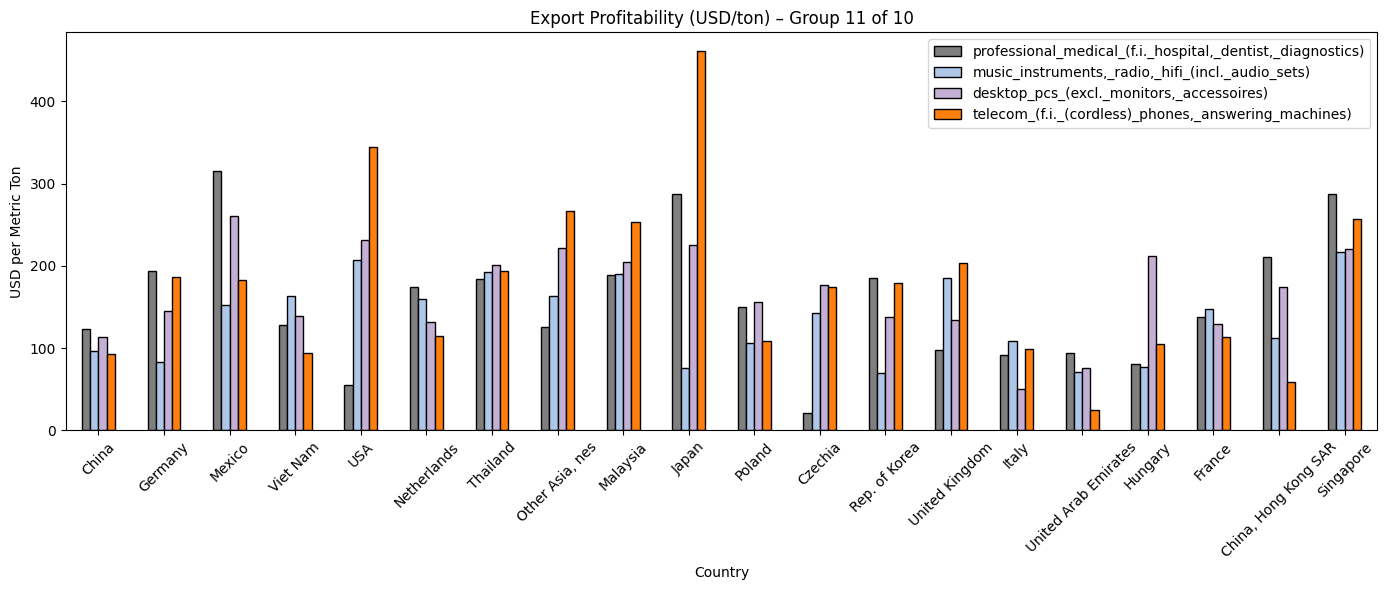

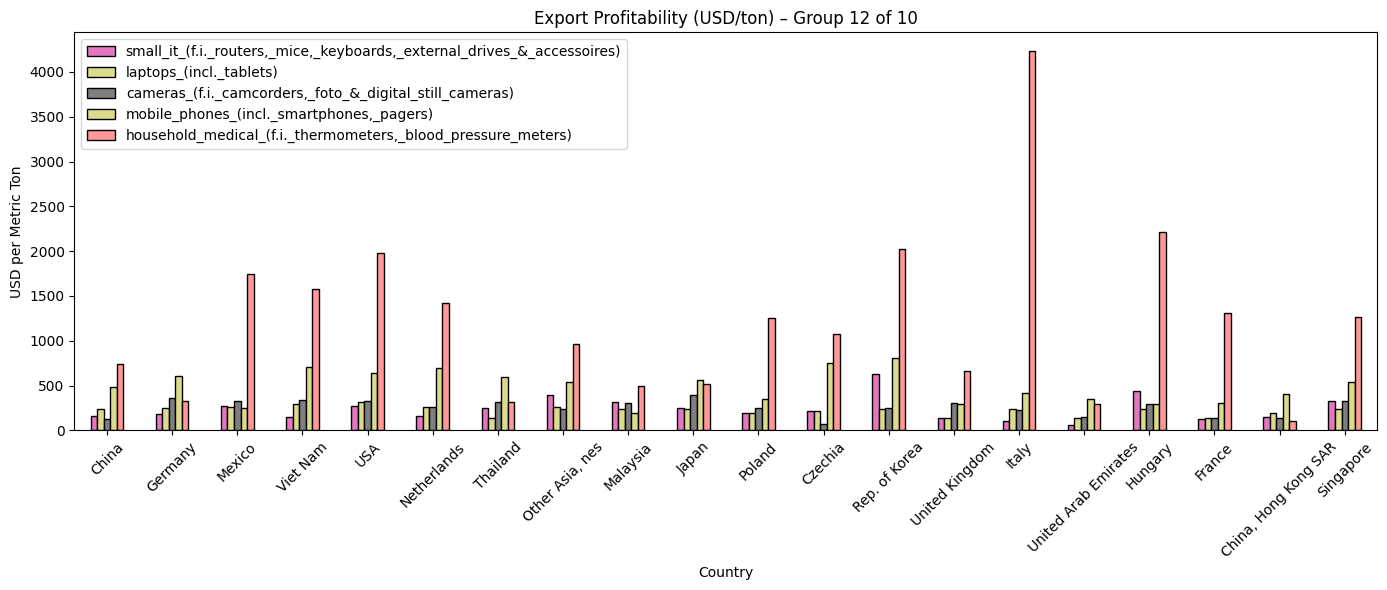

In [4]:
#  PREPARE DATA 
quantity_df_clean = quantity_df.replace(0, float('nan'))
value_per_ton_df = value_df / quantity_df_clean
value_per_ton_top = value_per_ton_df.loc[top_exporters]

# Remove infs and NaNs early for percentile calculation
value_per_ton_top = value_per_ton_top.replace([float('inf'), -float('inf')], pd.NA).dropna(axis=1, how='all')

# Compute median value/ton for each category
category_medians = value_per_ton_top.median().sort_values()

# Split into strata
num_strata = 10
categories = category_medians.index.tolist()
split_size = len(categories) // num_strata

category_groups = [categories[i:i+split_size] for i in range(0, len(categories), split_size)]

#ensure all categories are included
if len(category_groups) > num_strata:
    category_groups[-2].extend(category_groups[-1])
    category_groups = category_groups[:-1]

for i, group in enumerate(category_groups):
    subset = value_per_ton_top[group].copy()

    # Replace NaNs
    subset = subset.fillna(0)

    # Get corresponding colors
    valid_category_list = list(valid_categories)
    group_colors = [colors[valid_category_list.index(c)] for c in group if c in valid_category_list]

    fig, ax = plt.subplots(figsize=(14, 6))
    subset.plot(kind="bar", ax=ax, color=group_colors, edgecolor="black")

    ax.set_title(f"Export Profitability (USD/ton) – Group {i+1} of {num_strata}")
    ax.set_ylabel("USD per Metric Ton")
    ax.set_xlabel("Country")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


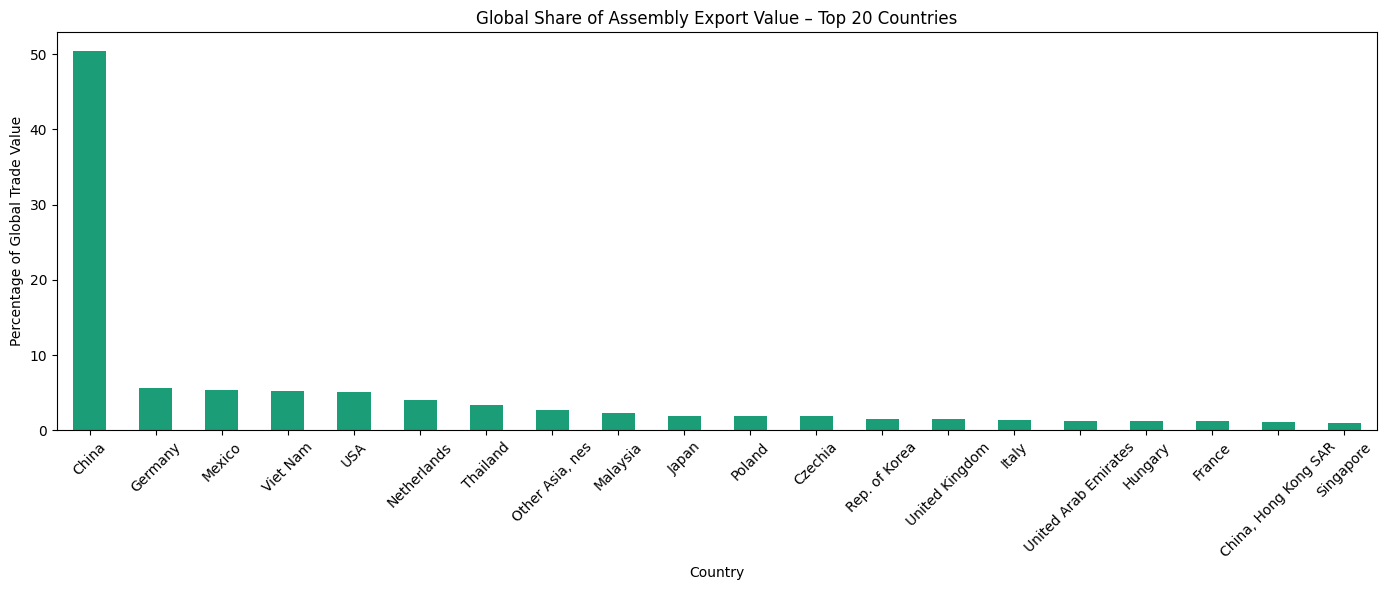

In [5]:
#  GLOBAL SHARE OF EXPORT VALUE (ASSEMBLY) 
global_total_value = value_df[valid_categories].sum().sum()
share_value = value_df[valid_categories].sum(axis=1) / global_total_value * 100

fig, ax = plt.subplots(figsize=(14, 6))
share_value.plot(kind='bar', ax=ax, color="#1b9e77")
ax.set_title("Global Share of Assembly Export Value – Top 20 Countries")
ax.set_ylabel("Percentage of Global Trade Value")
ax.set_xlabel("Country")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


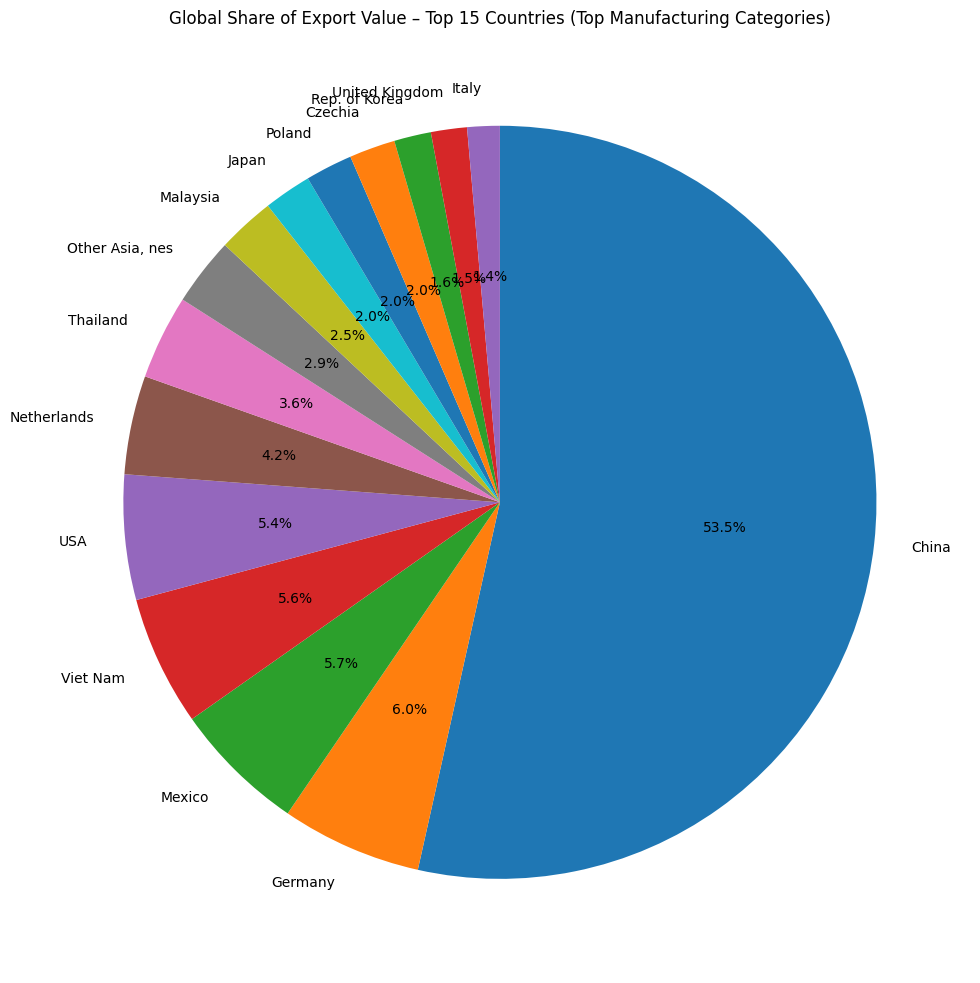

In [6]:
#  GLOBAL SHARE OF EXPORT VALUE (MANUFACTURING) 
global_total_value = value_df[valid_categories].sum().sum()
share_value = value_df[valid_categories].sum(axis=1) / global_total_value * 100
share_value_top = share_value[top_exporters[:15]]  # Top 15 exporters

fig, ax = plt.subplots(figsize=(10, 10))
ax.pie(
    share_value_top,
    labels=share_value_top.index,
    autopct="%1.1f%%",
    startangle=90,
    counterclock=False,
)
ax.set_title("Global Share of Export Value – Top 15 Countries (Top Manufacturing Categories)")
plt.tight_layout()
plt.show()


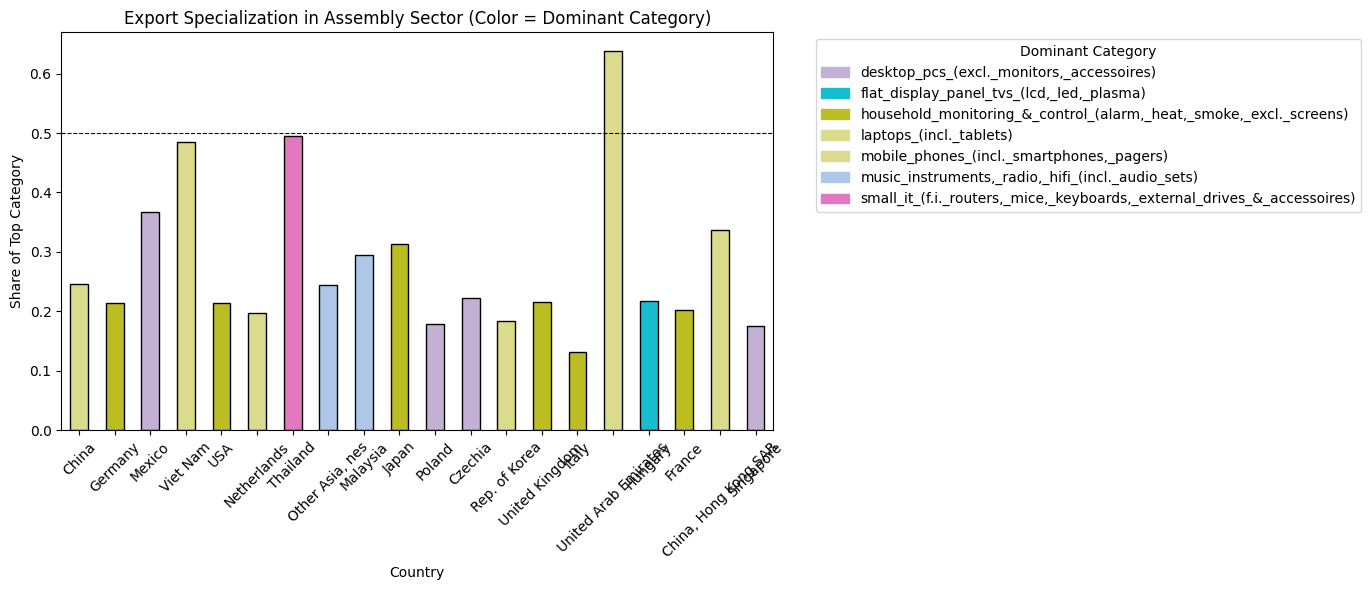

In [7]:
#  ASSEMBLY CATEGORY CONCENTRATION 
concentration_ratio = value_df[valid_categories].div(value_df[valid_categories].sum(axis=1), axis=0)
max_share_per_country = concentration_ratio.max(axis=1)
top_category_per_country = concentration_ratio.idxmax(axis=1)
bar_colors = [colors[list(valid_categories).index(cat)] for cat in top_category_per_country]

fig, ax = plt.subplots(figsize=(14, 6))
max_share_per_country.plot(kind='bar', ax=ax, color=bar_colors, edgecolor='black')
ax.set_title("Export Specialization in Assembly Sector (Color = Dominant Category)")
ax.set_ylabel("Share of Top Category")
ax.set_xlabel("Country")
plt.axhline(0.5, color="black", linestyle="--", linewidth=0.8)
plt.xticks(rotation=45)
ax.legend(
    handles=[plt.Rectangle((0, 0), 1, 1, color=colors[list(valid_categories).index(cat)]) for cat in sorted(set(top_category_per_country))],
    labels=sorted(set(top_category_per_country)),
    title="Dominant Category",
    bbox_to_anchor=(1.05, 1), loc="upper left"
)
plt.tight_layout()
plt.show()


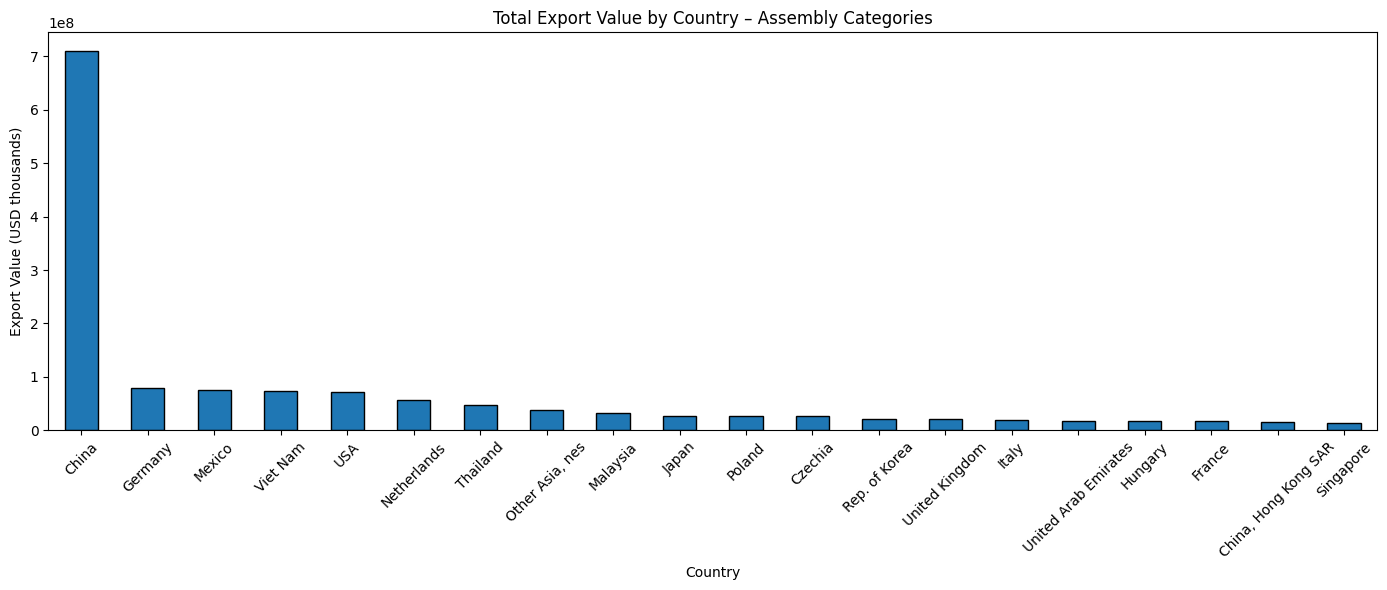

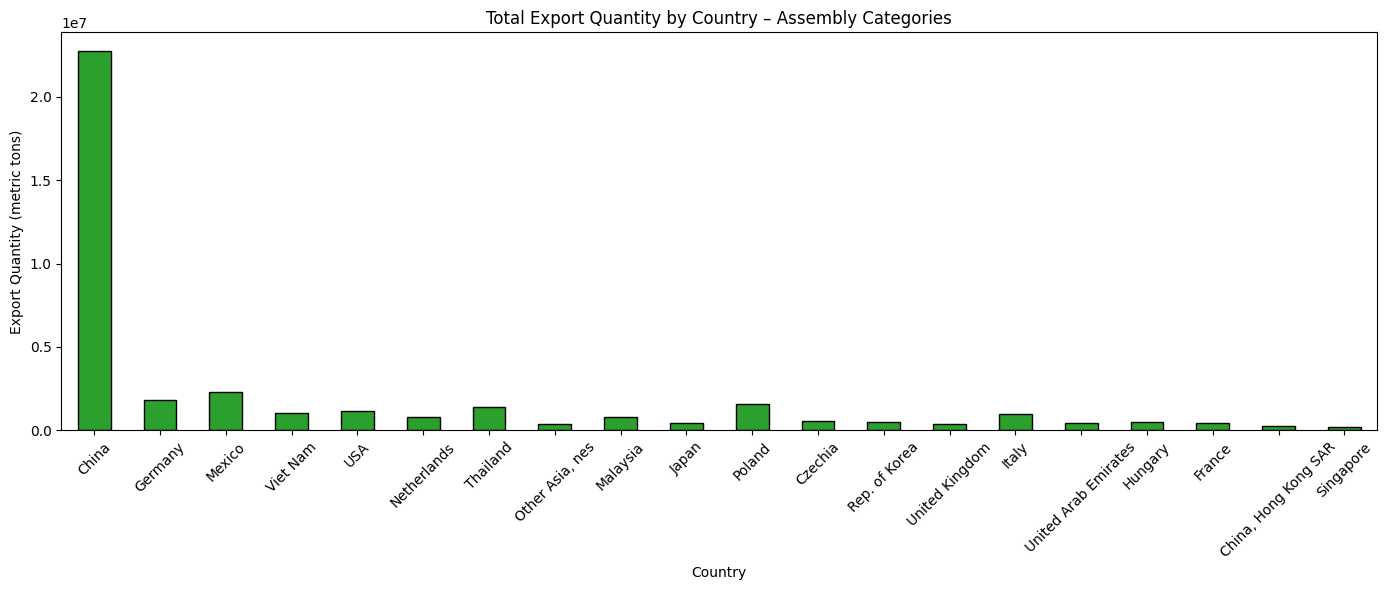

In [8]:
#  EXPORT VALUE VS QUANTITY: Assembly 

# Compute totals for selected categories
total_val = value_df[valid_categories].sum(axis=1)
total_qty = quantity_df[valid_categories].sum(axis=1)

# Select only top exporters
total_val_top = total_val[top_exporters]
total_qty_top = total_qty[top_exporters]

#  PLOT: Total Export Value 
fig, ax1 = plt.subplots(figsize=(14, 6))
total_val_top.plot(kind="bar", ax=ax1, color="#1f77b4", edgecolor="black")
ax1.set_title("Total Export Value by Country – Assembly Categories")
ax1.set_ylabel("Export Value (USD thousands)")
ax1.set_xlabel("Country")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#  PLOT: Total Export Quantity 
fig, ax2 = plt.subplots(figsize=(14, 6))
total_qty_top.plot(kind="bar", ax=ax2, color="#2ca02c", edgecolor="black")
ax2.set_title("Total Export Quantity by Country – Assembly Categories")
ax2.set_ylabel("Export Quantity (metric tons)")
ax2.set_xlabel("Country")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


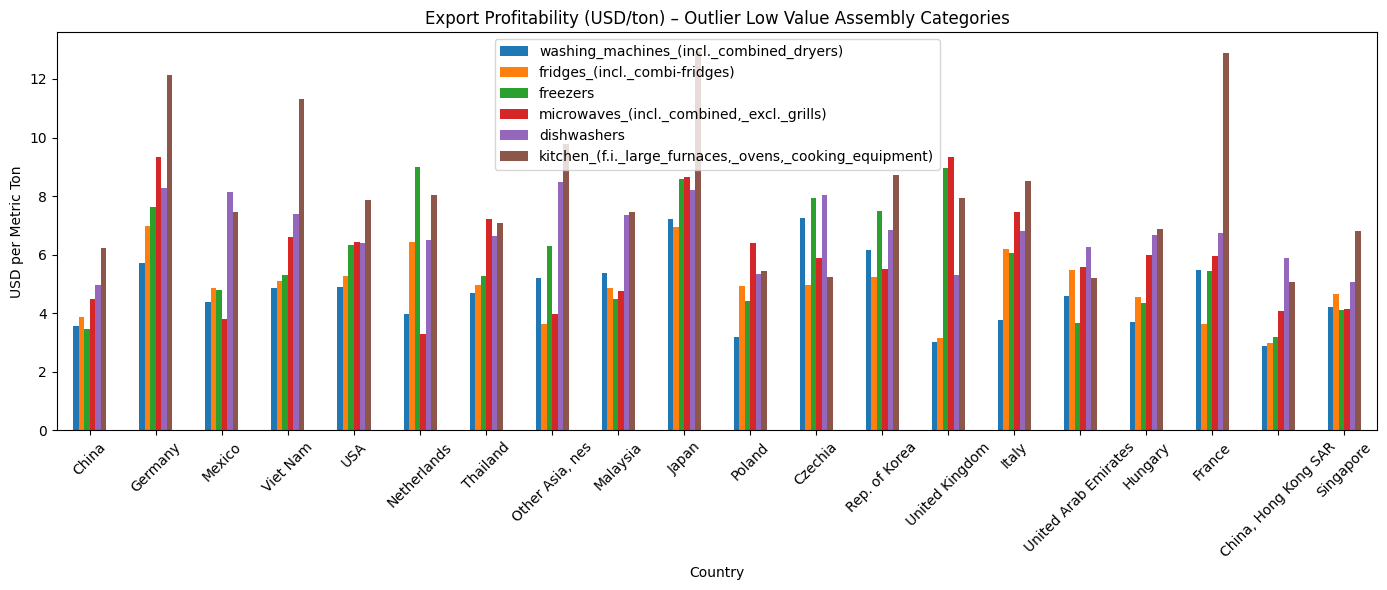

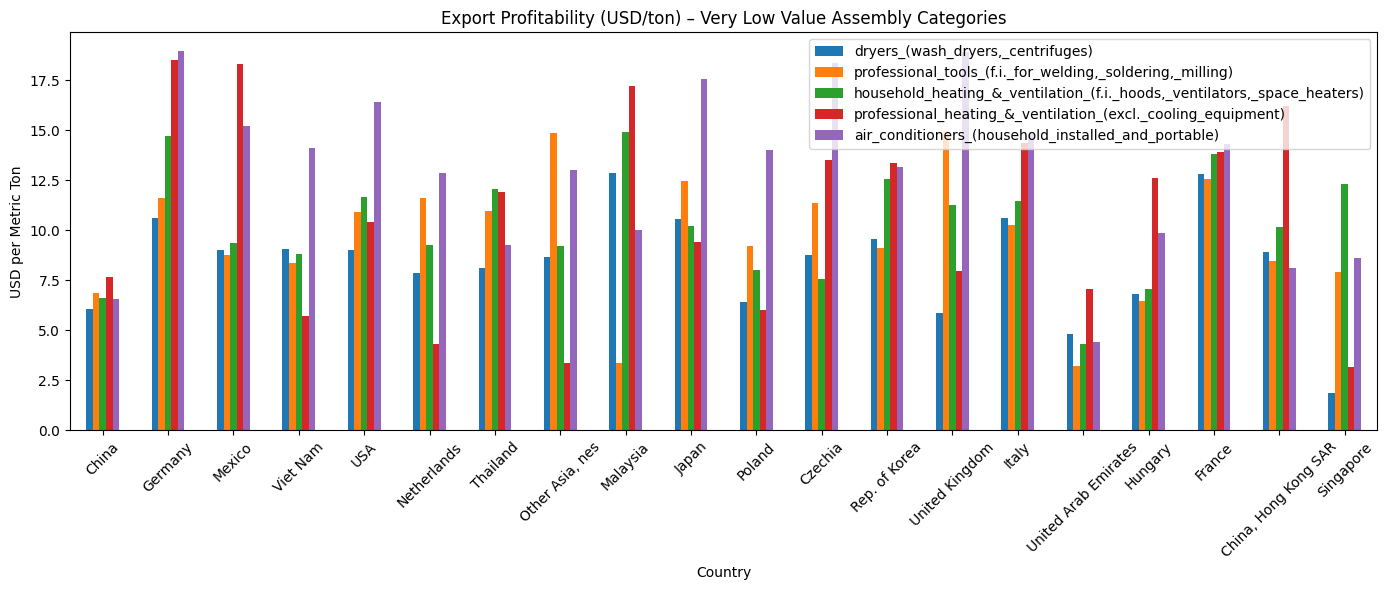

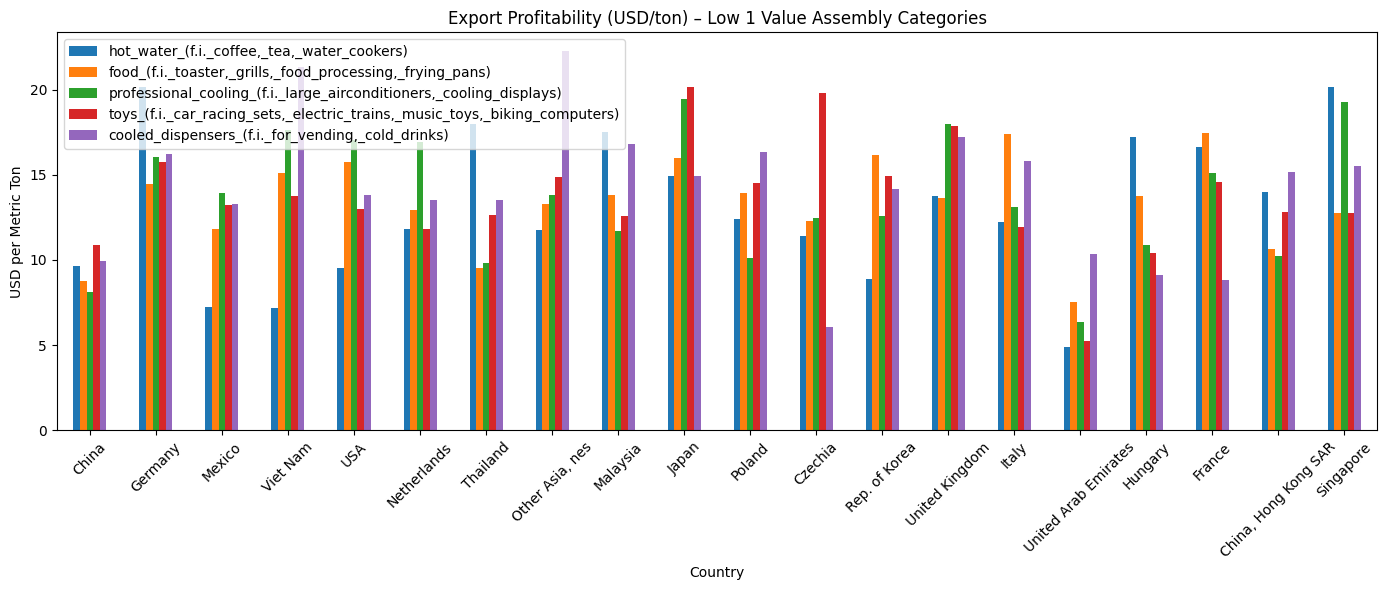

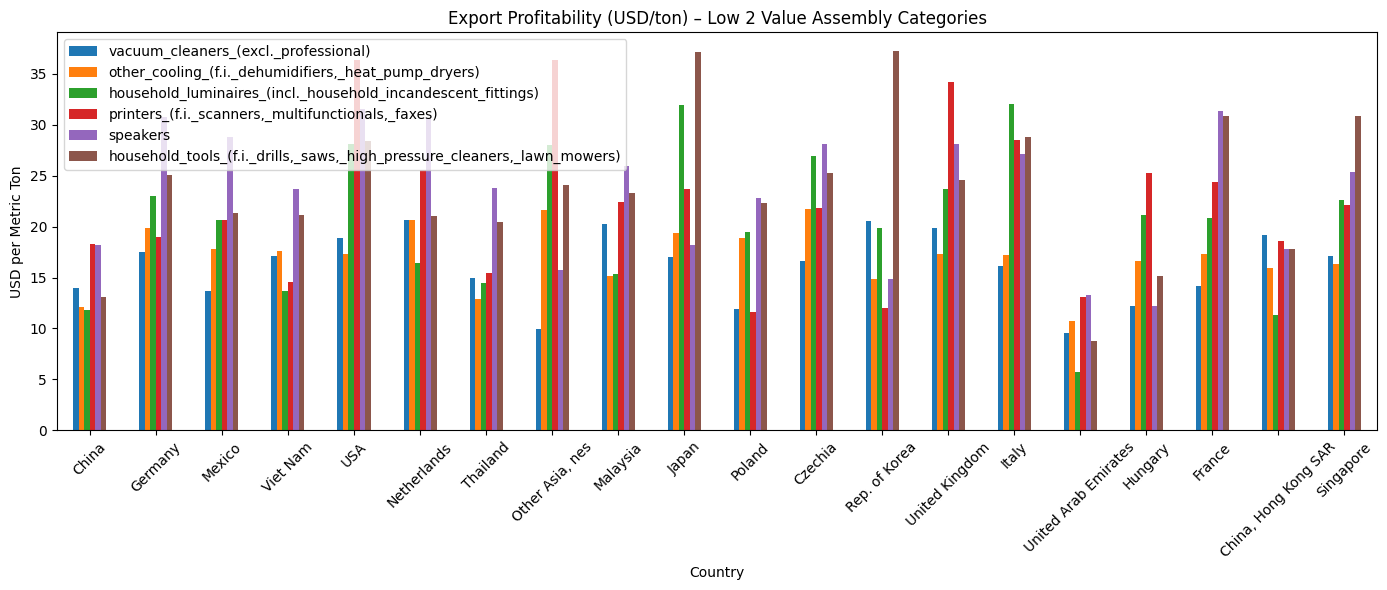

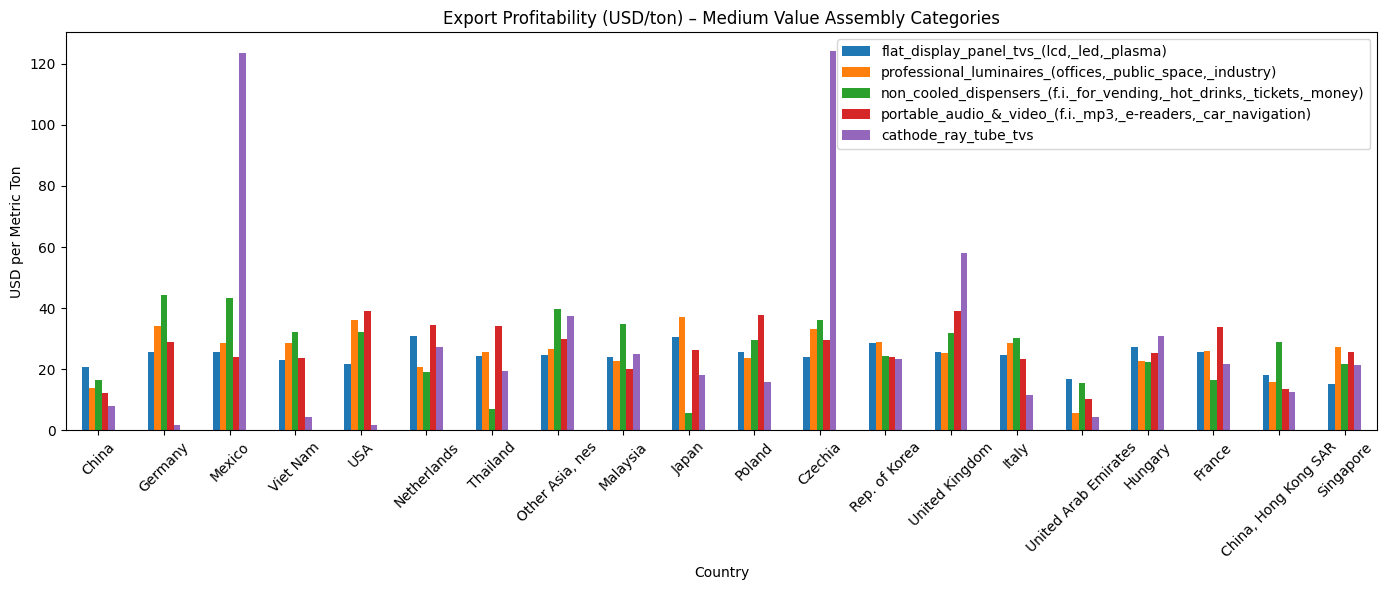

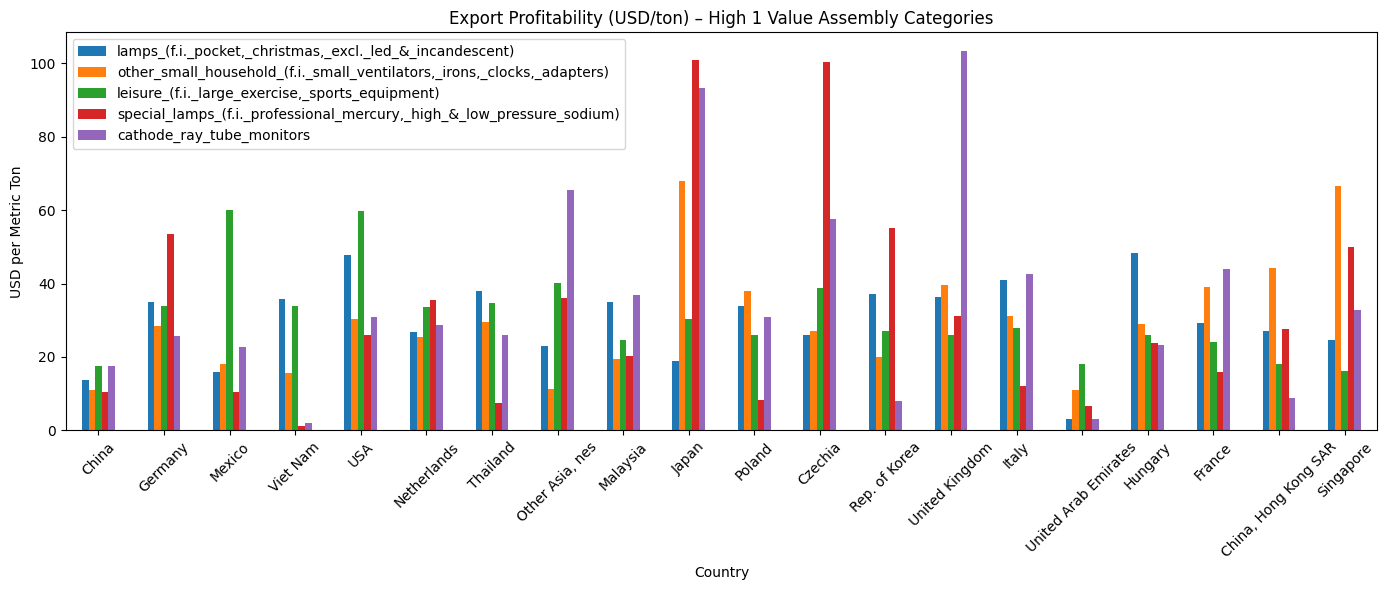

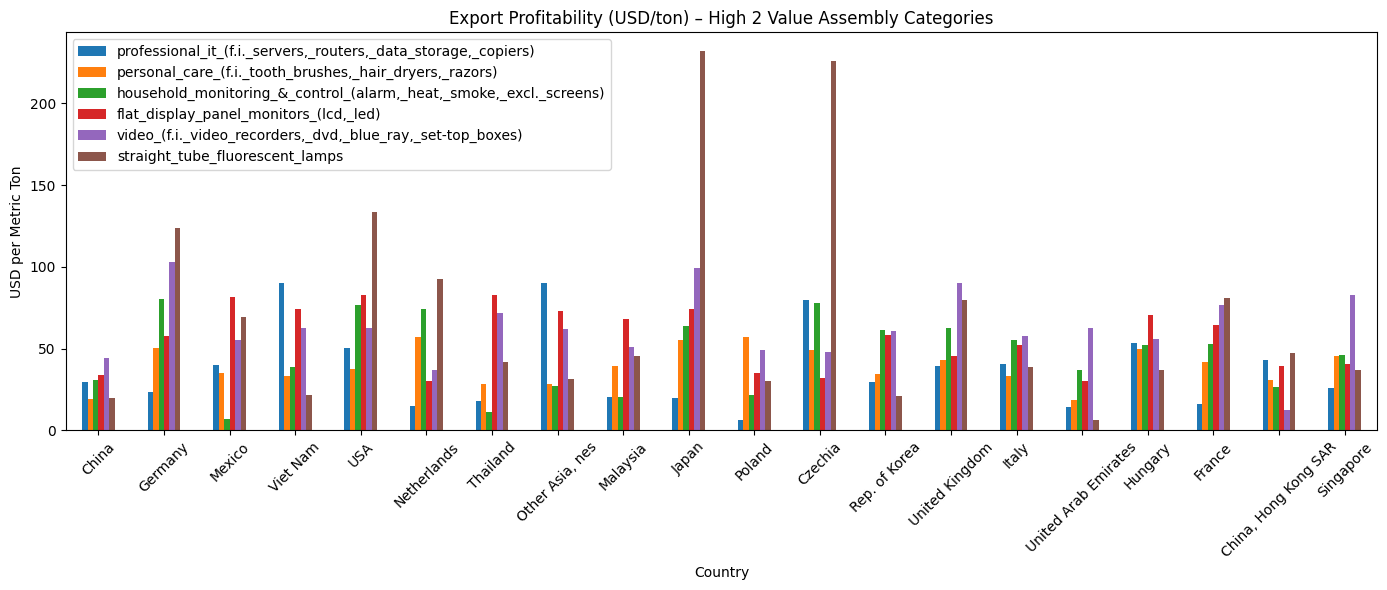

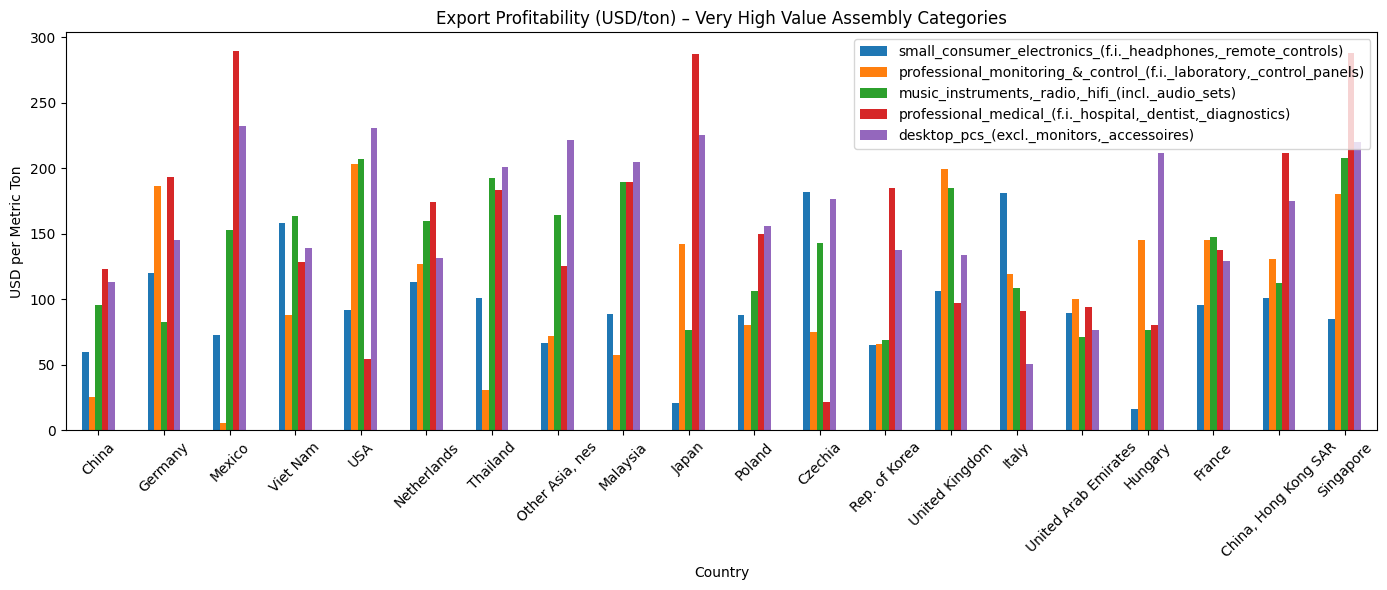

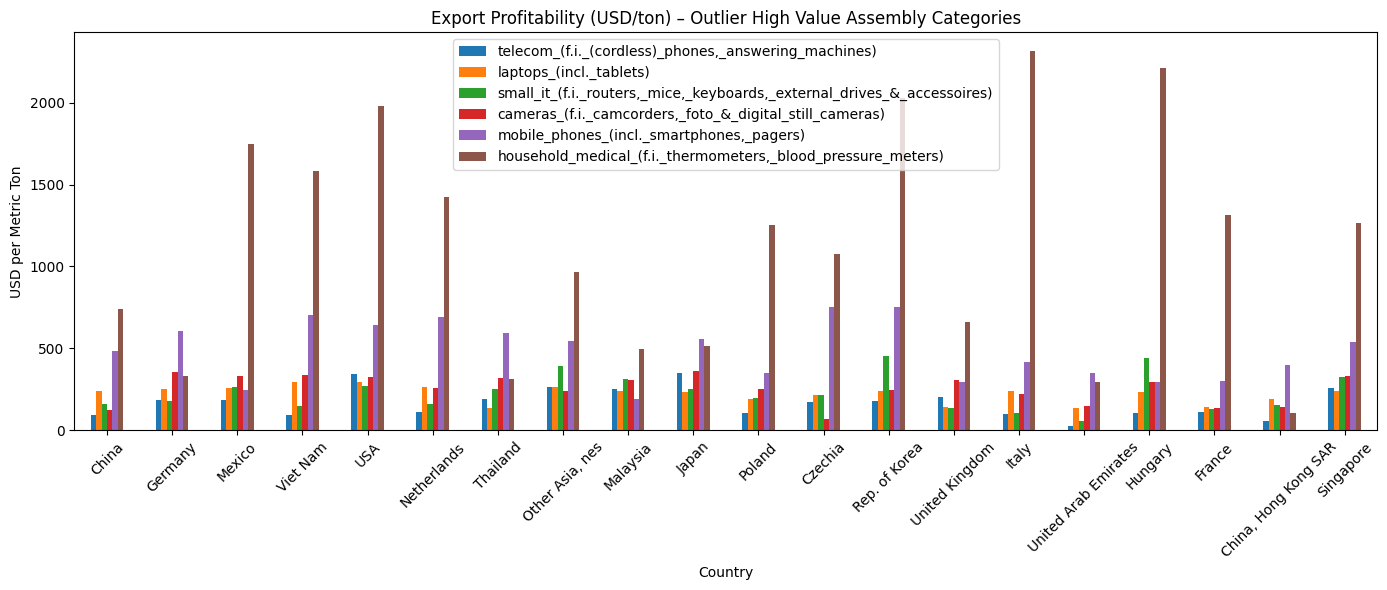

In [15]:
#  USD PER TON (STRATIFIED BY PRICE RANGE) FOR ASSEMBLY 

# Step 1: Clean and compute USD per ton
quantity_df_clean = quantity_df.replace(0, float("nan"))
value_per_ton_df = value_df / quantity_df_clean
value_per_ton_df = value_per_ton_df[valid_categories]  # valid_categories = assembly categories

# Step 2: Clip outliers at 95th percentile
clipped_df = value_per_ton_df.copy()
for col in clipped_df.columns:
    clip_val = clipped_df[col].quantile(0.95)
    clipped_df[col] = clipped_df[col].clip(upper=clip_val)

clipped_df = clipped_df.fillna(0)

# Step 3: Compute mean USD/ton per category across countries
category_means = clipped_df.mean().sort_values()

# Step 3.5: Handle duplicate bin edges error
if category_means.nunique() > 1:
    price_bins = pd.qcut(category_means, 9, labels=["Outlier Low", "Very Low", "Low 1", "Low 2", "Medium", "High 1", "High 2", "Very High", "Outlier High"], duplicates="drop")
else:
    # fallback: use cut if all means are too similar
    price_bins = pd.cut(category_means, bins=9, labels=["Outlier Low", "Very Low", "Low 1", "Low 2", "Medium", "High 1", "High 2", "Very High", "Outlier High"])

grouped_categories = {
    label: category_means[price_bins == label].index.tolist()
    for label in price_bins.unique()
    if label in price_bins.values
}

# Step 4: Plot each group separately
for label, group_cols in grouped_categories.items():
    if not group_cols:
        continue
    fig, ax = plt.subplots(figsize=(14, 6))
    clipped_df.loc[top_exporters, group_cols].plot(
        kind="bar",
        ax=ax,
        # color=[color_map.get(c, "#888888") for c in group_cols]
    )
    ax.set_title(f"Export Profitability (USD/ton) – {label} Value Assembly Categories")
    ax.set_ylabel("USD per Metric Ton")
    ax.set_xlabel("Country")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


In [16]:
value_df.to_csv("assembly_export_value.csv")
quantity_df.to_csv("assembly_export_quantity.csv")
